<a href="https://colab.research.google.com/github/DangLeUyen/Computer-Vision-From-Scratch/blob/main/NIH_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Import necessary libraries

In [22]:
import torch
from torchvision import datasets, transforms, models
import torch.nn as nn
import torch.optim as optim
import pathlib
from PIL import Image
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from torch.amp import autocast, GradScaler
import pandas as pd

device = "cuda" if torch.cuda.is_available() else "cpu"

### Mount to drive and Load the data

In [23]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
import zipfile
import os

# 1. Define the path to the zip file on Drive
zip_path = '/content/drive/MyDrive/Colab Notebooks/AUT/Dataset/NIH_subset.zip'

unzip_path = '/content/'

# 3. Create the directory if it doesn't exist
if not os.path.exists(unzip_path):
    os.makedirs(unzip_path)

# 4. Unzip the file
print(f"Unzipping {zip_path} to {unzip_path}...")

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(unzip_path)

print("Unzipping complete!")

Unzipping /content/drive/MyDrive/Colab Notebooks/AUT/Dataset/NIH_subset.zip to /content/...
Unzipping complete!


### Transform the dataset and create DataLoader

In [25]:
import os

def create_df(main_path, subfolder_name):
    # Define your paths
    path = main_path / subfolder_name
    csv_path = 'subset_16k_balanced.csv'

    # 1. Load your master CSV
    master_df = pd.read_csv(csv_path)

    # 2. Get a list of all filenames and their subfolder categories actually present
    image_data = []
    for category_folder in ['Disease', 'No_Disease']:
        category_path = path / category_folder
        if category_path.exists():
            files = [f for f in os.listdir(category_path) if not f.startswith('.')]
            for file in files:
                image_data.append({'Image Index': file, 'Category_Folder': category_folder})

    # Create a temporary DataFrame of physical files found with their category
    physical_files_df = pd.DataFrame(image_data)

    # 3. Merge to create the final sub_df with all metadata
    sub_df = pd.merge(master_df, physical_files_df, on='Image Index')

    return sub_df

In [26]:
from torch.utils.data import Dataset

# --- 1. MANDATORY: Custom Dataset to handle Bias Metadata ---
class ChestXrayBiasDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.df = dataframe
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        # Construct the image path including the Category_Folder
        img_path = f"{self.image_dir}/{row['Category_Folder']}/{row['Image Index']}"
        image = Image.open(img_path).convert('RGB')

        label = torch.tensor(row['Binary_Label']).float()
        # Encode metadata as numbers for the DataLoader
        gender = 1.0 if row['Patient Gender'] == 'F' else 0.0
        position = 1.0 if row['View Position'] == 'AP' else 0.0

        if self.transform:
            image = self.transform(image)

        return image, label, gender, position

In [27]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_CHANNELS = 3
BATCH_SIZE = 32
NUM_EPOCHS = 30
LEARNING_RATE = 1e-4
CHECKPOINT_PATH = '/content/drive/MyDrive/Colab Notebooks/AUT/chest_xray_bias_model.pth'

data_transform = {
    "train": transforms.Compose([
        #transforms.Resize((224, 224)),
        transforms.RandomRotation(15),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    "val": transforms.Compose([
        #transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

main_path = '/content/chest_data'
main_path = pathlib.Path(main_path)
train_dataset = ChestXrayBiasDataset(create_df(main_path, 'Train'), '/content/chest_data/Train', data_transform['train'])
val_dataset = ChestXrayBiasDataset(create_df(main_path, 'Val'), '/content/chest_data/Val', data_transform['val'])
test_dataset = ChestXrayBiasDataset(create_df(main_path, 'Test'), '/content/chest_data/Test', data_transform['val'])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, num_workers=2)

### Write necessary functions: training, testing, and plotting results

In [28]:
import numpy as np
import torch

class EarlyStopping:
    def __init__(self, patience=3, verbose=False, path='best_model.pth'):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        self.path = path

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(val_loss, model)
        elif val_loss > self.best_loss:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        '''Saves model when validation loss decreases.'''
        torch.save(model.state_dict(), self.path)

In [29]:

# --- Training Function ---
def train_model(model, criterion, optimizer, train_loader, val_loader, scheduler=None, epochs=10):
    # Initialize Early Stopping
    early_stopping = EarlyStopping(patience=3, verbose=True, path=CHECKPOINT_PATH)
    res = {'train_accuracy': [], 'val_accuracy': [], 'train_loss': [], 'val_loss': []}
    scaler = GradScaler()

    for epoch in range(epochs):
        model.train()
        train_correct, train_total, running_loss = 0, 0, 0.0

        for images, labels, _, _ in train_loader: # Metadata ignored during training
            images, labels = images.to(device), labels.to(device).view(-1, 1)

            optimizer.zero_grad()
            with autocast(device_type=device): # Corrected: Pass device_type
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward() # Corrected: Call .backward() on scaled loss
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item()
            preds = (torch.sigmoid(outputs) > 0.5).float()
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)

        train_acc = train_correct / train_total
        avg_train_loss = running_loss / len(train_loader)

        # VALIDATION
        model.eval()
        val_correct, val_total, val_running_loss = 0, 0, 0.0
        with torch.no_grad():
            for images, labels, _, _ in val_loader:
                images, labels = images.to(device), labels.to(device).view(-1, 1)
                outputs = model(images)
                v_loss = criterion(outputs, labels)
                val_running_loss += v_loss.item()

                preds = (torch.sigmoid(outputs) > 0.5).float()
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_acc = val_correct / val_total
        avg_val_loss = val_running_loss / len(val_loader)

        if scheduler:
            scheduler.step(avg_val_loss)

        print(f"Epoch {epoch+1}/{epochs} | Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f}")

        res['train_accuracy'].append(train_acc)
        res['val_accuracy'].append(val_acc)
        res['train_loss'].append(avg_train_loss)
        res['val_loss'].append(avg_val_loss)

        # CHECK EARLY STOPPING
        early_stopping(avg_val_loss, model)
        if early_stopping.early_stop:
            print("Early stopping triggered. Training halted.")
            break

    # FIXED: Indentation corrected to load best weights before returning
    try:
        model.load_state_dict(torch.load(CHECKPOINT_PATH))
        print("Loaded best model weights.")
    except Exception as e:
        print(f"Warning: Could not load best weights: {e}")

    return res

# --- Bias Evaluation ---
def evaluate_bias(model, test_loader):
    model.eval()
    all_preds, all_labels, all_genders, all_views = [], [], [], []

    with torch.no_grad():
        for images, labels, genders, positions in test_loader:
            images = images.to(device)
            outputs = model(images)
            preds = (torch.sigmoid(outputs) > 0.5).float().cpu().numpy()

            all_preds.extend(preds.flatten())
            all_labels.extend(labels.numpy().flatten())
            all_genders.extend(genders.numpy().flatten())
            all_views.extend(positions.numpy().flatten())

    results_df = pd.DataFrame({
        'Gender': ['Female' if g == 1 else 'Male' for g in all_genders],
        'View': ['AP' if v == 1 else 'PA' for v in all_views],
        'True': all_labels,
        'Pred': all_preds
    })
    results_df['Correct'] = (results_df['True'] == results_df['Pred']).astype(int)

    bias_report = results_df.groupby(['Gender', 'View'])['Correct'].mean().reset_index()
    print("\n--- ACCURACY BY DEMOGRAPHIC/TECHNICAL GROUP ---")
    print(bias_report)
    return results_df

# --- Plotting ---
def plot_bias(results_df):
    plt.figure(figsize=(10, 6))
    # CI=None removed for newer Seaborn versions, use errorbar=None
    sns.barplot(data=results_df, x='View', y='Correct', hue='Gender', errorbar=None)
    plt.title('Model Accuracy: Gender Bias across View Positions')
    plt.ylabel('Accuracy')
    plt.ylim(0, 1)
    plt.axhline(results_df['Correct'].mean(), color='red', linestyle='--', label='Global Avg')
    plt.legend()
    plt.show()

### Using pretrained DenseNet model for training

In [30]:
model = models.densenet121(weights='IMAGENET1K_V1')

# 1. Freeze all feature (backbone) layers
for param in model.features.parameters():
    param.requires_grad = False

# 2. Correctly identify input features (it is 1024 for DenseNet-121)
n_features = model.classifier.in_features

model.classifier = nn.Sequential(
            nn.Linear(n_features, 1) # Changed output features from 2 to 1 for binary classification
)

# The newly added Linear layer in the classifier has requires_grad=True by default.
# The Sigmoid layer is implicitly handled by BCEWithLogitsLoss for numerical stability.

model = model.to(device)

# 5. Re-initialize optimizer to only track parameters with requires_grad=True
# Filter parameters that require gradients
trainable_params = [p for p in model.parameters() if p.requires_grad]

if len(trainable_params) == 0:
    raise ValueError("No parameters are set to requires_grad=True. Check your freezing logic!")

# Initialize Optimizer
optimizer = optim.Adam(trainable_params, lr=LEARNING_RATE)

# Binary Cross Entropy with Logits (includes Sigmoid internally for stability)
criterion = nn.BCEWithLogitsLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.1, mode='min', patience=1)

# Execute Training
print(f"Starting training on {device}...")
res = train_model(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    scheduler=scheduler,
    epochs=NUM_EPOCHS
)

Starting training on cuda...
Epoch 1/30 | Train Acc: 0.514 | Val Acc: 0.562
Epoch 2/30 | Train Acc: 0.588 | Val Acc: 0.598
Epoch 3/30 | Train Acc: 0.611 | Val Acc: 0.609
Epoch 4/30 | Train Acc: 0.623 | Val Acc: 0.628
Epoch 5/30 | Train Acc: 0.631 | Val Acc: 0.631
Epoch 6/30 | Train Acc: 0.635 | Val Acc: 0.644
Epoch 7/30 | Train Acc: 0.636 | Val Acc: 0.647
Epoch 8/30 | Train Acc: 0.638 | Val Acc: 0.646
Epoch 9/30 | Train Acc: 0.642 | Val Acc: 0.651
Epoch 10/30 | Train Acc: 0.646 | Val Acc: 0.651
Epoch 11/30 | Train Acc: 0.639 | Val Acc: 0.649
Epoch 12/30 | Train Acc: 0.639 | Val Acc: 0.646
Epoch 13/30 | Train Acc: 0.640 | Val Acc: 0.654
Epoch 14/30 | Train Acc: 0.644 | Val Acc: 0.656
Epoch 15/30 | Train Acc: 0.638 | Val Acc: 0.656
Epoch 16/30 | Train Acc: 0.637 | Val Acc: 0.658
EarlyStopping counter: 1 out of 3
Epoch 17/30 | Train Acc: 0.648 | Val Acc: 0.653
EarlyStopping counter: 2 out of 3
Epoch 18/30 | Train Acc: 0.645 | Val Acc: 0.659
EarlyStopping counter: 3 out of 3
Early stopping

In [31]:
from torch.serialization import save
results_df = evaluate_bias(model, test_loader)
results_df.to_csv('/content/drive/MyDrive/Colab Notebooks/AUT/results_df.csv', index=False)


--- ACCURACY BY DEMOGRAPHIC/TECHNICAL GROUP ---
   Gender View   Correct
0  Female   AP  0.644860
1  Female   PA  0.625000
2    Male   AP  0.669761
3    Male   PA  0.660584


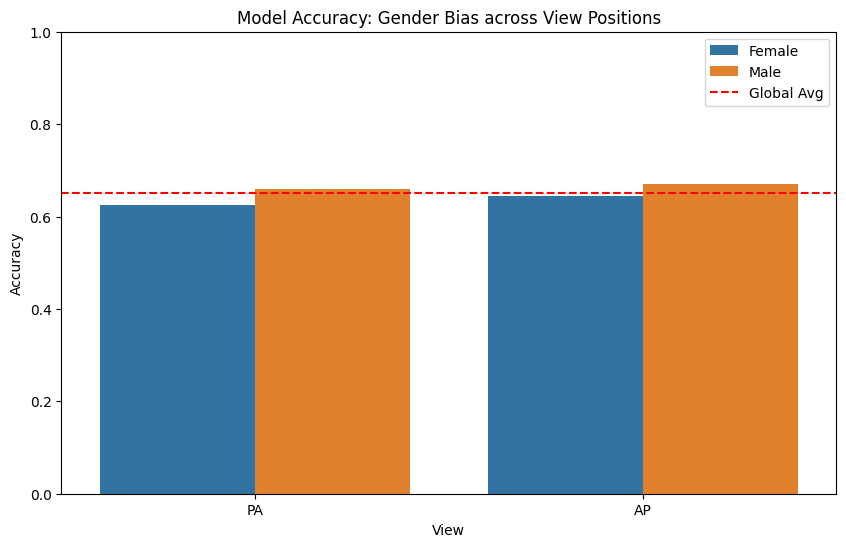

In [32]:
plot_bias(results_df)